In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

student_performance_on_an_entrance_examination = fetch_ucirepo(id=582)

X = student_performance_on_an_entrance_examination.data.features
y = student_performance_on_an_entrance_examination.data.targets

print(student_performance_on_an_entrance_examination.metadata)

print(student_performance_on_an_entrance_examination.variables)


{'uci_id': 582, 'name': 'Student Performance on an Entrance Examination', 'repository_url': 'https://archive.ics.uci.edu/dataset/582/student+performance+on+an+entrance+examination', 'data_url': 'https://archive.ics.uci.edu/static/public/582/data.csv', 'abstract': 'This dataset contains data of the candidates who qualified the medical entrance examination for admission to medical colleges of Assam of a particular year and collected by Prof. Jiten Hazarika.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 666, 'num_features': 11, 'feature_types': [], 'demographics': ['Gender', 'Education Level', 'Occupation'], 'target_col': ['Performance'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Tue Apr 16 2024', 'dataset_doi': '10.24432/C58D0H', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Performance, Gender, Caste, coaching, C

In [ ]:
pip install scipy pandas


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving CEE_DATA.csv to CEE_DATA.csv


In [ ]:
from scipy.io import arff
import pandas as pd

filename = list(uploaded.keys())[0]

data, meta = arff.loadarff(filename)

df = pd.DataFrame(data)

df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)

csv_filename = filename.replace(".arff", ".csv")
df.to_csv(csv_filename, index=False)

csv_filename


/tmp/ipython-input-3093832612.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


'CEE_DATA.csv'

In [ ]:
files.download(csv_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving CEE_DATA.csv to CEE_DATA (1).csv


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()


,Performance,Gender,Caste,coaching,time,Class_ten_education,twelve_education,medium,Class_ X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation
0,Excellent,male,General,NO,ONE,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS
1,Excellent,male,OBC,WA,TWO,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE
2,Excellent,male,OBC,OA,TWO,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE
3,Excellent,male,General,WA,ONE,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER
4,Excellent,male,General,OA,TWO,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE


In [ ]:
target_column = df.columns[0]


X = df.drop(columns=[target_column])
y = df[target_column]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop(columns=[target_column])
y = df[target_column]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)

clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.425


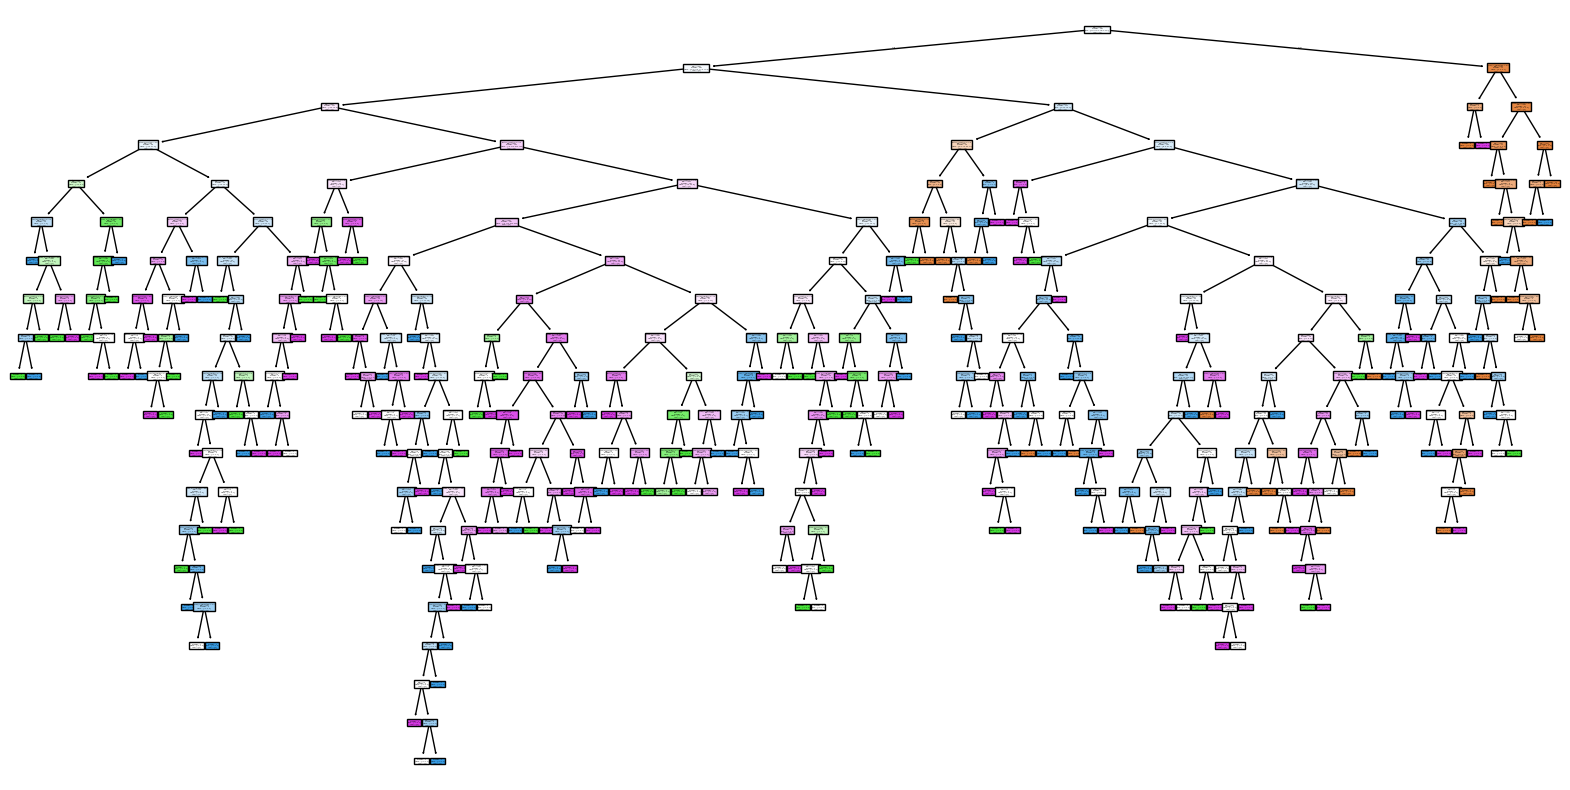

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=True, filled=True)
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv("CEE_DATA.csv")
df.head()


,Performance,Gender,Caste,coaching,time,Class_ten_education,twelve_education,medium,Class_ X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation
0,Excellent,male,General,NO,ONE,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS
1,Excellent,male,OBC,WA,TWO,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE
2,Excellent,male,OBC,OA,TWO,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE
3,Excellent,male,General,WA,ONE,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER
4,Excellent,male,General,OA,TWO,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le_dict = {}

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le


In [ ]:
target = "Performance"
feature_columns = df_encoded.columns.drop(target)

X = df_encoded[feature_columns]
y = df_encoded[target]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)


DecisionTreeClassifier(random_state=42)

In [ ]:
sample_input = pd.DataFrame([{
    "Gender": "male",
    "Caste": "General",
    "coaching": "NO",
    "time": "ONE",
    "Class_ten_education": "SEBA",
    "twelve_education": "AHSEC",
    "medium": "ENGLISH",
    "Class_ X_Percentage": "Excellent",
    "Class_XII_Percentage": "Excellent",
    "Father_occupation": "DOCTOR",
    "Mother_occupation": "OTHERS"
}])


In [ ]:
for col in sample_input.columns:
    if col in le_dict:
        sample_input[col] = le_dict[col].transform(sample_input[col])


In [ ]:
prediction = clf.predict(sample_input)

predicted_label = le_dict[target].inverse_transform(prediction)
print("Predicted Performance:", predicted_label[0])


Predicted Performance: Excellent


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le_dict = {}

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le

target = "Performance"
feature_columns = [
    "Gender",
    "time",
    "medium",
    "Class_ X_Percentage",
    "Class_XII_Percentage",
    "Father_occupation",
    "Mother_occupation"
]

X = df_encoded[feature_columns]
y = df_encoded[target]

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

sample_input = pd.DataFrame([{
    "Gender": "male",
    "time": "ONE",
    "medium": "ENGLISH",
    "Class_ X_Percentage": "Excellent",
    "Class_XII_Percentage": "Excellent",
    "Father_occupation": "DOCTOR",
    "Mother_occupation": "OTHERS"
}])

for col in sample_input.columns:
    if col in le_dict:
        sample_input[col] = le_dict[col].transform(sample_input[col])

prediction = clf.predict(sample_input)
predicted_label = le_dict[target].inverse_transform(prediction)

print("Predicted Performance:", predicted_label[0])


Predicted Performance: Excellent


In [ ]:
import pickle

with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(clf, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(le_dict, f)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # Example classifier
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error
import numpy as np

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train, average='weighted')
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
rae_train = np.sum(np.abs(y_train - y_pred_train)) / np.sum(np.abs(y_train - np.mean(y_train)))

acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='weighted')
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
rae_test = np.sum(np.abs(y_test - y_pred_test)) / np.sum(np.abs(y_test - np.mean(y_test)))

print("=== Training Set Metrics ===")
print(f"Accuracy: {acc_train:.4f}")
print(f"F1-Score: {f1_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"RAE: {rae_train:.4f}")

print("\n=== Test Set Metrics ===")
print(f"Accuracy: {acc_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"RAE: {rae_test:.4f}")


=== Training Set Metrics ===
Accuracy: 0.9421
F1-Score: 0.9421
RMSE: 0.3903
MAE: 0.0880
RAE: 0.0902

=== Test Set Metrics ===
Accuracy: 0.4350
F1-Score: 0.4195
RMSE: 1.0677
MAE: 0.7400
RAE: 0.7229
